In [1]:
import kagglehub
path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")
print("Path to dataset files:", path)

100%|██████████| 89.0M/89.0M [00:40<00:00, 2.30MB/s]

Extracting files...


Path to dataset files: C:\Users\celin\.cache\kagglehub\datasets\himanshupoddar\zomato-bangalore-restaurants\versions\1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
path = r"C:\Users\celin\.cache\kagglehub\datasets\himanshupoddar\zomato-bangalore-restaurants\versions\1\zomato.csv"
df = pd.read_csv(path, encoding='latin-1')

print(f"✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

✅ Dataset loaded!
Shape: (51717, 17)

Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
# ── Data Health Check ──────────────────────────────────────
print("=== DATASET OVERVIEW ===")
print(f"Total Restaurants: {len(df)}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nSample ratings:")
print(df['rate'].value_counts().head(10))

=== DATASET OVERVIEW ===
Total Restaurants: 51717

Null values:
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

Data types:
url                              str
address                          str
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
phone                 

In [4]:
# ── Data Cleaning ──────────────────────────────────────────

# 1. Clean rate column — remove '/5', spaces, handle 'NEW' and '-'
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.replace('/5', '').str.strip()
df['rate'] = df['rate'].str.replace(' ', '')
df['rate'] = df['rate'].replace(['NEW', 'nan', '-'], np.nan)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# 2. Clean cost column — remove commas, convert to number
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '').str.strip()
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# 3. Rename columns for easier use
df.rename(columns={
    'approx_cost(for two people)': 'cost',
    'listed_in(type)': 'meal_type',
    'listed_in(city)': 'city'
}, inplace=True)

# 4. Drop unnecessary columns
df.drop(columns=['url', 'phone', 'dish_liked', 'menu_item', 'reviews_list'], inplace=True)

print("✅ Data Cleaned!")
print(f"\nRating range: {df['rate'].min()} to {df['rate'].max()}")
print(f"Cost range: ₹{df['cost'].min()} to ₹{df['cost'].max()}")
print(f"\nShape after cleaning: {df.shape}")
df.head()

✅ Data Cleaned!

Rating range: 1.8 to 4.9
Cost range: ₹40.0 to ₹6000.0

Shape after cleaning: (51717, 12)


,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,meal_type,city
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


In [5]:
# ── Key Insights ───────────────────────────────────────────

print("=== ZOMATO BANGALORE INSIGHTS ===")

# 1. Online ordering
print("\n1. Online Order Availability:")
print(df['online_order'].value_counts())
print(f"   {round(df['online_order'].value_counts(normalize=True)['Yes']*100, 1)}% restaurants offer online ordering")

# 2. Table booking
print("\n2. Table Booking Availability:")
print(df['book_table'].value_counts())
print(f"   Only {round(df['book_table'].value_counts(normalize=True)['Yes']*100, 1)}% restaurants allow table booking")

# 3. Average rating
print(f"\n3. Average Rating: {df['rate'].mean():.2f} / 5")
print(f"   Highest rated: {df.loc[df['rate'].idxmax(), 'name']} ({df['rate'].max()})")

# 4. Most popular locations
print("\n4. Top 10 locations with most restaurants:")
print(df['location'].value_counts().head(10))

# 5. Most popular cuisines
print("\n5. Top 10 cuisines:")
print(df['cuisines'].value_counts().head(10))

# 6. Cost vs Rating correlation
corr = df['cost'].corr(df['rate'])
print(f"\n6. Correlation between Cost and Rating: {corr:.2f}")
if corr > 0.3:
    print("   Higher cost restaurants tend to have better ratings!")
else:
    print("   Cost doesn't strongly predict rating!")

=== ZOMATO BANGALORE INSIGHTS ===

1. Online Order Availability:
online_order
Yes    30444
No     21273
Name: count, dtype: int64
   58.9% restaurants offer online ordering

2. Table Booking Availability:
book_table
No     45268
Yes     6449
Name: count, dtype: int64
   Only 12.5% restaurants allow table booking

3. Average Rating: 3.70 / 5
   Highest rated: Byg Brewski Brewing Company (4.9)

4. Top 10 locations with most restaurants:
location
BTM                      5124
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
Whitefield               2144
Indiranagar              2083
Jayanagar                1926
Marathahalli             1846
Bannerghatta Road        1630
Bellandur                1286
Name: count, dtype: int64

5. Top 10 cuisines:
cuisines
North Indian                           2913
North Indian, Chinese                  2385
South Indian                           1828
Biryani                                 918
Bakery, Desserts    

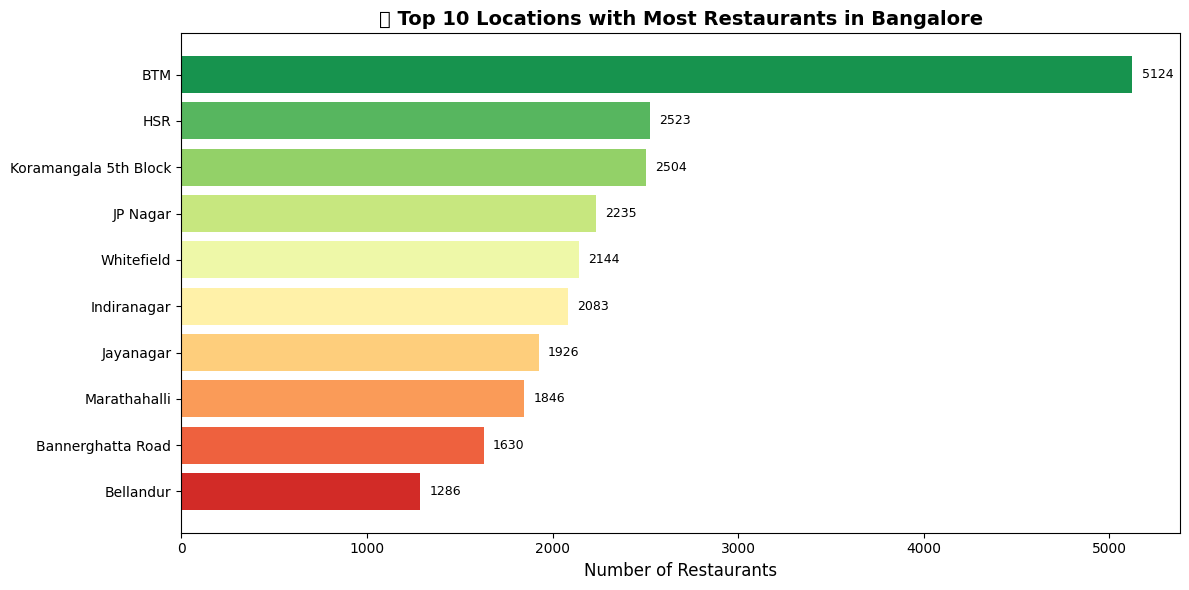

✅ Chart 1 saved!


In [6]:
# ── Chart 1: Top 10 Locations ──────────────────────────────
plt.figure(figsize=(12, 6))
top_locations = df['location'].value_counts().head(10)
colors = sns.color_palette('RdYlGn', 10)
bars = plt.barh(top_locations.index[::-1], top_locations.values[::-1], color=colors)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.title('🗺️ Top 10 Locations with Most Restaurants in Bangalore', 
          fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_locations.values[::-1]):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
             str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_locations.png', dpi=150)
plt.show()
print("✅ Chart 1 saved!")

<Figure size 1000x500 with 0 Axes>

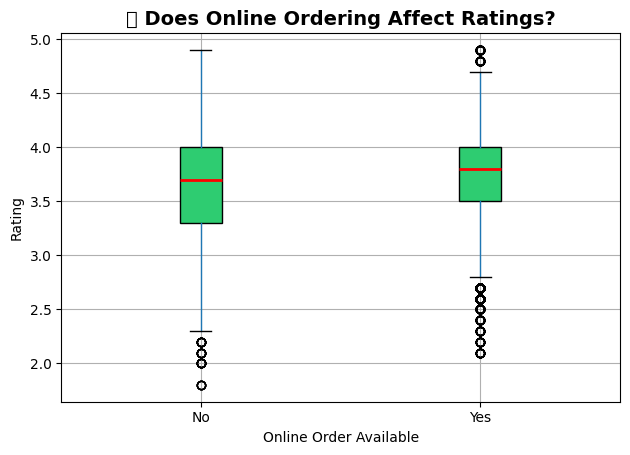

✅ Chart 2 saved!


In [7]:
# ── Chart 2: Online Order vs Rating ───────────────────────
plt.figure(figsize=(10, 5))
df.boxplot(column='rate', by='online_order', 
           patch_artist=True,
           boxprops=dict(facecolor='#2ecc71', color='black'),
           medianprops=dict(color='red', linewidth=2))
plt.title('⭐ Does Online Ordering Affect Ratings?', 
          fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Online Order Available')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('online_vs_rating.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

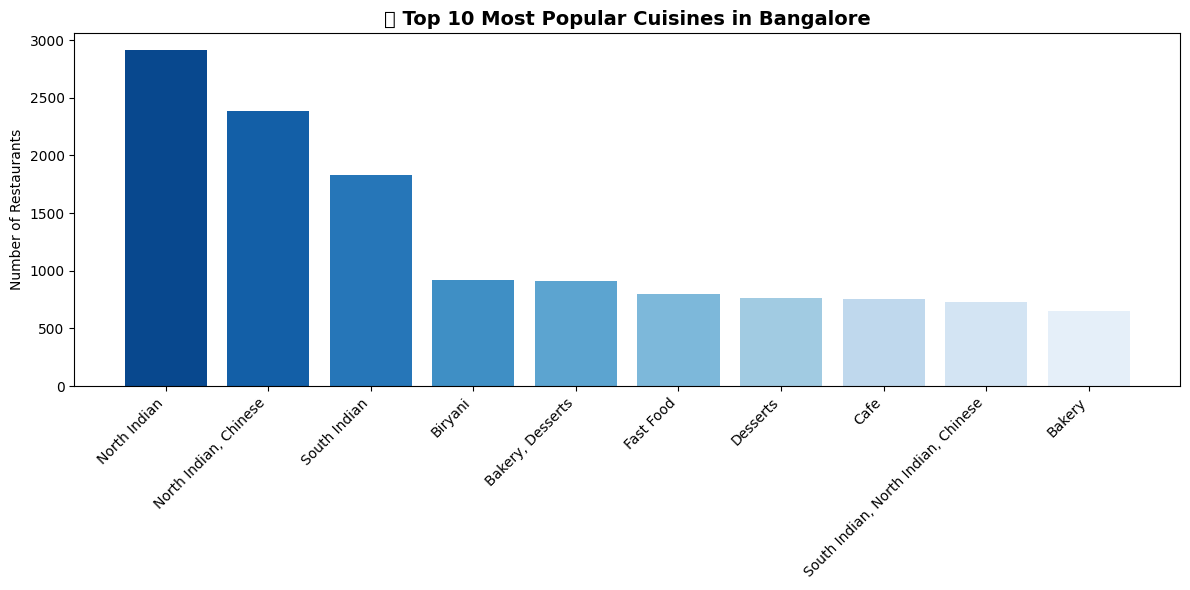

✅ Chart 3 saved!


In [8]:
# ── Chart 3: Top Cuisines ──────────────────────────────────
plt.figure(figsize=(12, 6))
top_cuisines = df['cuisines'].value_counts().head(10)
plt.bar(range(len(top_cuisines)), top_cuisines.values, 
        color=sns.color_palette('Blues_r', 10))
plt.xticks(range(len(top_cuisines)), top_cuisines.index, rotation=45, ha='right')
plt.ylabel('Number of Restaurants')
plt.title('🍽️ Top 10 Most Popular Cuisines in Bangalore', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_cuisines.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

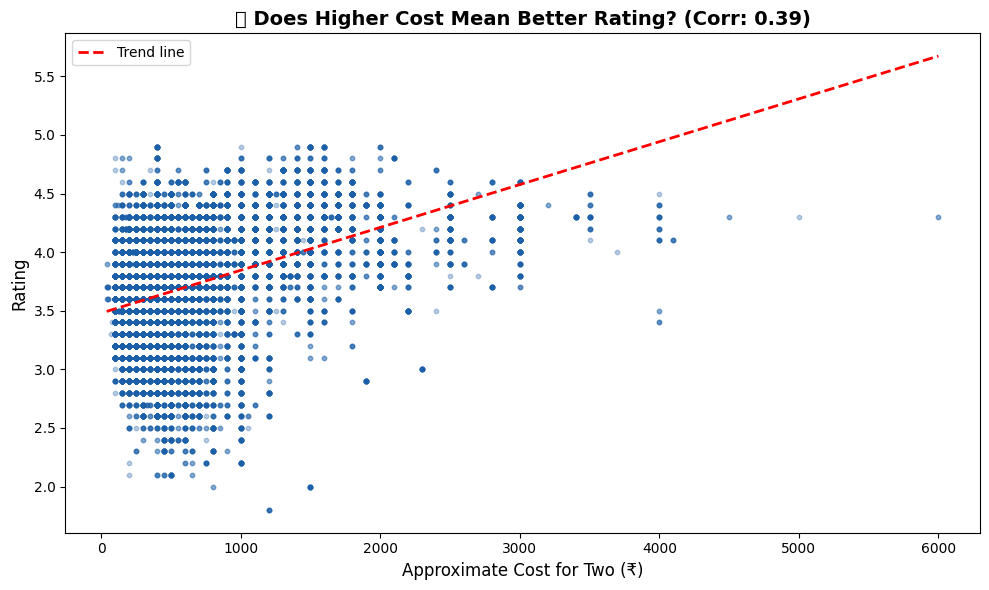

✅ Chart 4 saved!


In [10]:
# ── Chart 4: Cost vs Rating Scatter ───────────────────────
# Drop nulls from both columns together
df_clean = df[['cost', 'rate']].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(df_clean['cost'], df_clean['rate'], alpha=0.3, 
            color='#1a5fa8', s=10)
plt.xlabel('Approximate Cost for Two (₹)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.title('💰 Does Higher Cost Mean Better Rating? (Corr: 0.39)', 
          fontsize=14, fontweight='bold')
z = np.polyfit(df_clean['cost'], df_clean['rate'], 1)
p = np.poly1d(z)
plt.plot(sorted(df_clean['cost']), 
         p(sorted(df_clean['cost'])), 
         "r--", linewidth=2, label='Trend line')
plt.legend()
plt.tight_layout()
plt.savefig('cost_vs_rating.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")

In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '🗺️ Top 10 Locations',
        '🍽️ Top 10 Cuisines',
        '💰 Cost vs Rating',
        '⭐ Online Order vs Rating'
    ),
    vertical_spacing=0.2,
    horizontal_spacing=0.15
)

# Panel 1: Top Locations
top_loc = df['location'].value_counts().head(10)
fig.add_trace(go.Bar(
    x=top_loc.values,
    y=top_loc.index,
    orientation='h',
    marker_color='#2ecc71',
    hovertemplate='<b>%{y}</b><br>Restaurants: %{x}<extra></extra>',
    name='Locations'
), row=1, col=1)

# Panel 2: Top Cuisines — shortened labels
top_cui = df['cuisines'].value_counts().head(10)
short_labels = [c[:15] + '...' if len(c) > 15 else c for c in top_cui.index]
fig.add_trace(go.Bar(
    x=short_labels,
    y=top_cui.values,
    marker_color='#1a5fa8',
    hovertemplate='<b>%{x}</b><br>Count: %{y}<extra></extra>',
    name='Cuisines'
), row=1, col=2)

# Panel 3: Cost vs Rating
df_clean = df[['cost', 'rate']].dropna()
fig.add_trace(go.Scatter(
    x=df_clean['cost'],
    y=df_clean['rate'],
    mode='markers',
    marker=dict(color='#1a5fa8', size=4, opacity=0.4),
    hovertemplate='Cost: ₹%{x}<br>Rating: %{y}<extra></extra>',
    name='Cost vs Rating'
), row=2, col=1)

# Panel 4: Online Order vs Rating
for order_type, color in [('Yes', '#2ecc71'), ('No', '#e74c3c')]:
    fig.add_trace(go.Box(
        y=df[df['online_order']==order_type]['rate'].dropna(),
        name=f'Online: {order_type}',
        marker_color=color,
        hovertemplate='Rating: %{y}<extra></extra>'
    ), row=2, col=2)

fig.update_layout(
    title=dict(
        text='🍽️ Zomato Bangalore Restaurant Analysis',
        font=dict(size=20),
        x=0.5
    ),
    height=900,
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11)
)

# Fix cuisine label rotation
fig.update_xaxes(tickangle=45, row=1, col=2)
fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0')
fig.update_yaxes(showgrid=True, gridcolor='#f0f0f0')

fig.write_html('zomato_dashboard.html')
fig.show()
print("✅ Dashboard fixed and saved!")

✅ Dashboard fixed and saved!
